# LABORATORIO 2 — Pronóstico de caudal con ASDA

## Implementación académica adaptada con Adaptive SSA, Dual Attention y RSD Loss

Objetivo: usar 336 horas históricas para pronosticar las siguientes 48 horas de caudal específico.

### Experimentos
- **E1:** Baseline LSTM.
- **E2:** ASDA adaptado: Adaptive SSA + BQA + Dual LSTM + TSA + RSD.
- **E3:** Ablación sin Dual Attention.

### Convención visual
<div style="border-left:6px solid #2563eb;padding:6px 10px;background:#eff6ff"><b>PAPER</b> — elemento proveniente del artículo ASDA.</div>
<div style="border-left:6px solid #16a34a;padding:6px 10px;background:#f0fdf4"><b>ADAPTACIÓN LAB2</b> — cambio requerido por nuestro dataset.</div>
<div style="border-left:6px solid #d97706;padding:6px 10px;background:#fffbeb"><b>ESTRATEGIA COMPUTACIONAL</b> — optimización que no cambia el método.</div>
<div style="border-left:6px solid #7c3aed;padding:6px 10px;background:#f5f3ff"><b>RÚBRICA LAB2</b> — evidencia solicitada por el laboratorio.</div>

### Flujo principal
```text
Adaptive SSA → BQA → Dual LSTM → TSA → ŷ[48] → RSD Loss
```

SSA+BQA se precalculan; soft-DTW usa wavefront; el entrenamiento usa early stopping por RMSE de validation.

## 0. Mapa E2E de la solución

```text
X [N,336,12]
 ├─ Meteorología [N,336,11]
 └─ Caudal [N,336]
        ↓
 Adaptive SSA                     [PAPER]
        ↓
Trend + Fluctuation
        ↓
       BQA                        [PAPER]
        ↓
CACHE PRECALCULADO                [ESTRATEGIA]
        ↓
Dual LSTM                         [PAPER]
        ↓
TSA                               [PAPER]
        ↓
ŷ [N,48]                          [ADAPTACIÓN]
        ↓
RSD = RMSE + soft-DTW             [PAPER]
        ↓
Backpropagation
        ↓
Early stopping por RMSE val       [ESTRATEGIA]
```

SSA y BQA son deterministas en esta implementación, por eso se calculan una sola vez. soft-DTW depende de la predicción actual y permanece dentro del entrenamiento.

<div style="border-left:6px solid #16a34a;padding:8px 12px;background:#f0fdf4">
<b>ADAPTACIÓN LAB2</b> — Cambio necesario para aplicar el método al dataset y al horizonte del laboratorio.
</div>

## 1. Paper vs adaptación al LAB 2

| Elemento | Paper | LAB 2 |
|---|---|---|
| Problema | Runoff urbano | Pronóstico de caudal |
| Resolución | 10 min | 1 hora |
| Entrada | Principalmente runoff histórico | Caudal + 11 variables meteorológicas |
| Historia | Secuencias cortas del paper | 336 horas |
| Horizonte | 1–6 pasos | 48 horas |
| Adaptive SSA | Sobre runoff | Sobre canal `specific_discharge` |
| BQA | Antes de LSTM | Se conserva |
| Dual LSTM | Trend / Fluctuation | Se conserva + meteorología como contexto |
| TSA | Después de LSTM | Se conserva en versión académica |
| RSD Loss | RMSE + soft-DTW | Se conserva |
| KW sampling | Sí | Se omite: dataset ya viene muestreado/spliteado |
| TPE | Sí | Se omite: no es necesario para el objetivo académico |

## 2. Imports y reproducibilidad

In [3]:
import json
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("No se encontró la carpeta src del proyecto.")

SOURCE_DIR = str(PROJECT_ROOT / "src")
if SOURCE_DIR not in sys.path:
    sys.path.insert(0, SOURCE_DIR)

from leer_datos import CaudalDataset
from asda import (
    ASDA,
    BaselineLSTM,
    rsd_loss,
    soft_dtw,
    soft_dtw_referencia,
    ssa_filtros,
)
from soporte import (
    DatosConPrecalculo,
    DatosNormalizados,
    estadisticas_train,
    entrenar,
    nombre_cache,
    predecir,
    predecir_test,
    precalcular_asda,
    seleccionar_indices,
)

SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu130
Dispositivo: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb"><b>ESTRATEGIA COMPUTACIONAL</b> — Optimización de ejecución. No cambia el método ASDA.</div>

## 3. Configuración final de entrega

Se utiliza **todo el dataset**.

Los valores 10/6/6 usados en pruebas anteriores no provienen del paper. El paper reporta un máximo de 220 épocas dentro de su propio ajuste de hiperparámetros.

Para el LAB se usa **early stopping sobre RMSE de validation**:
- E1: máximo 10 épocas.
- E2/E3: máximo 6 épocas.
- patience = 2.
- mínimo 2 épocas antes de permitir detener.
- se restaura siempre el mejor estado observado.


In [4]:
max_train_samples = None
max_validation_samples = None
max_test_samples = None
max_stats_samples = None

max_epochs_baseline = 10
max_epochs_asda = 6
patience = 2
min_epochs = 2

batch_size = 16
batch_cache_ssa = 32
hidden_size = 64

epsilon_ssa = 0.05
theta_ssa = 0.01

lambda_rmse = 0.817
lambda_soft_dtw = 0.23
gamma_soft_dtw = 0.1

cache_dir = PROJECT_ROOT / "artifacts" / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)

checkpoints_dir = PROJECT_ROOT / "artifacts" / "checkpoints"
checkpoints_dir.mkdir(parents=True, exist_ok=True)

outputs_dir = PROJECT_ROOT / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

forzar_recalculo_cache = False

TIEMPOS = {}
INICIO_NOTEBOOK = time.perf_counter()

print("CONFIGURACIÓN FINAL")
print("train/validation/test: dataset completo")
print("batch_size:", batch_size)
print("early stopping:", f"patience={patience}, min_epochs={min_epochs}")
print("máximos:", f"E1={max_epochs_baseline}, E2/E3={max_epochs_asda}")

CONFIGURACIÓN FINAL
train/validation/test: dataset completo
batch_size: 16
early stopping: patience=2, min_epochs=2
máximos: E1=10, E2/E3=6


<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

## 4. Carga de datos y splits

Se reutiliza `CaudalDataset`, entregado para el laboratorio.

No se carga todo HDF5 en RAM: cada muestra se consulta bajo demanda.

In [5]:
metadata = json.loads((PROJECT_ROOT / "data" / "metadata.json").read_text())

train_data = CaudalDataset(str(PROJECT_ROOT / "data" / "train.h5"), split="train")
validation_data = CaudalDataset(str(PROJECT_ROOT / "data" / "train.h5"), split="validation")
test_data = CaudalDataset(str(PROJECT_ROOT / "data" / "test.h5"), split="test")

muestra = train_data[0]

print("train:", len(train_data))
print("validation:", len(validation_data))
print("test:", len(test_data))
print("X:", muestra["X"].shape)
print("y:", muestra["y"].shape)

assert muestra["X"].shape == (336, 12)
assert muestra["y"].shape == (48,)

train: 254000
validation: 18142
test: 27983
X: (336, 12)
y: (48,)


<div style="border-left:6px solid #16a34a;padding:8px 12px;background:#f0fdf4">
<b>ADAPTACIÓN LAB2</b> — Cambio necesario para aplicar el método al dataset y al horizonte del laboratorio.
</div>

### 4.1 Canales del LAB

El paper trabaja principalmente con runoff. Nuestro dataset aporta información meteorológica adicional.

- canales `0..10`: meteorología;
- canal `11`: `specific_discharge`.

SSA se aplica **solo al caudal histórico**. Las variables meteorológicas entran después como contexto de las ramas LSTM.

In [6]:
for i, canal in enumerate(metadata["channels"]):
    print(f"{i:2d}: {canal['name']}")

print("\nMeteorología: X[:, :11]")
print("Caudal:       X[:, 11]")

 0: convective_fraction
 1: longwave_radiation
 2: potential_energy
 3: potential_evaporation
 4: pressure
 5: shortwave_radiation
 6: specific_humidity
 7: temperature
 8: total_precipitation
 9: wind_u
10: wind_v
11: specific_discharge

Meteorología: X[:, :11]
Caudal:       X[:, 11]


<div style="border-left:6px solid #16a34a;padding:8px 12px;background:#f0fdf4">
<b>ADAPTACIÓN LAB2</b> — Cambio necesario para aplicar el método al dataset y al horizonte del laboratorio.
</div>

### 4.2 Una muestra: 336 horas conocidas → 48 horas futuras

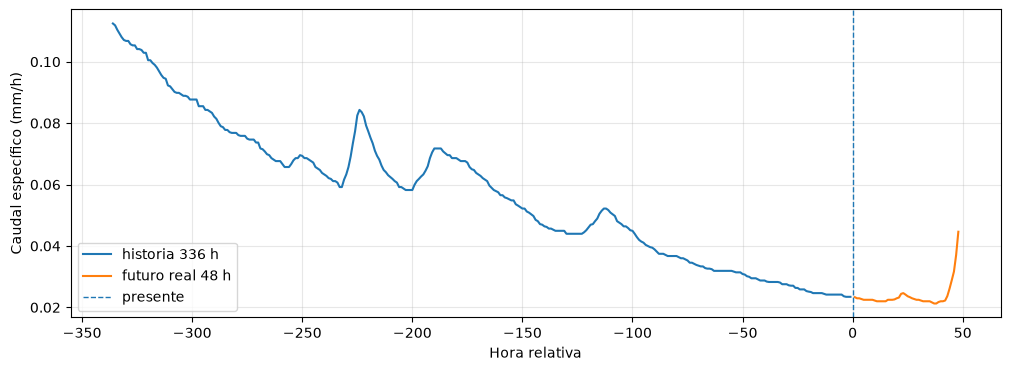

In [7]:
caudal_hist = muestra["X"][:, 11]
caudal_futuro = muestra["y"]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(-336, 0), caudal_hist, label="historia 336 h")
plt.plot(np.arange(1, 49), caudal_futuro, label="futuro real 48 h")
plt.axvline(0, linestyle="--", linewidth=1, label="presente")
plt.xlabel("Hora relativa")
plt.ylabel("Caudal específico (mm/h)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="border-left:6px solid #16a34a;padding:8px 12px;background:#f0fdf4">
<b>ADAPTACIÓN LAB2</b> — Cambio necesario para aplicar el método al dataset y al horizonte del laboratorio.
</div>

## 5. Normalización

Normalizamos cada canal mediante Z-score:

$$
x' = \frac{x-\mu}{\sigma}
$$

Calculamos las estadísticas exclusivamente con el conjunto de entrenamiento y reutilizamos esos mismos parámetros en validation y test. De esta forma evitamos incorporar información de validation o test durante el preprocesamiento.

El paper aplica `log(1+x)` y Z-score sobre runoff. En nuestra adaptación utilizamos Z-score multivariado sin una transformación logarítmica global, debido a que algunas variables meteorológicas pueden tomar valores negativos.

In [8]:
_t0 = time.perf_counter()

media_x, std_x, media_y, std_y = estadisticas_train(
    train_data,
    limite=max_stats_samples,
)

print("media_x:", media_x.shape)
print("std_x:", std_x.shape)
print("media_y:", media_y)
print("std_y:", std_y)

TIEMPOS["Estadísticas train"] = time.perf_counter() - _t0
print(f"Tiempo estadísticas: {TIEMPOS['Estadísticas train']/60:.3f} min")


media_x: (12,)
std_x: (12,)
media_y: 0.06619422823679127
std_y: 0.16116449849210496
Tiempo estadísticas: 0.900 min


In [9]:
def normalizar_X(X):
    return ((X - media_x) / std_x).astype(np.float32)

def normalizar_y(y):
    return ((y - media_y) / std_y).astype(np.float32)

def desnormalizar_y(y):
    return y * std_y + media_y

assert np.allclose(
    desnormalizar_y(normalizar_y(muestra["y"])),
    muestra["y"],
    atol=1e-5,
)

<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb">
<b>ESTRATEGIA COMPUTACIONAL</b> — No cambia el método del paper. Reduce tiempo de ejecución o evita trabajo repetido.
</div>

## 6. Selección de índices

Definimos una selección reproducible mediante una semilla fija. En la corrida final utilizamos el conjunto completo de train, validation y test, por lo que los límites de muestras quedan desactivados.

La misma lógica de índices se mantiene para E1, E2 y E3, garantizando que los experimentos comparen los mismos registros.

In [10]:
indices_train = seleccionar_indices(
    len(train_data),
    max_train_samples,
    SEMILLA,
)

indices_validation = seleccionar_indices(
    len(validation_data),
    max_validation_samples,
    SEMILLA + 1,
)

indices_test = seleccionar_indices(
    len(test_data),
    max_test_samples,
    SEMILLA + 2,
)

print("train usado:", len(indices_train))
print("validation usado:", len(indices_validation))
print("test usado:", len(indices_test))


train usado: 254000
validation usado: 18142
test usado: 27983


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

## 7. Adaptive SSA y control de data leakage

Conservamos el procesamiento central de Adaptive SSA:

1. definimos `L = N/2`;
2. construimos la matriz de trayectoria;
3. aplicamos SVD;
4. calculamos la contribución de cada componente;
5. agrupamos las componentes mediante los filtros adaptativos:
   - **Trend:** contribución `>= ε`;
   - **Fluctuation:** `θ <= contribución < ε`;
   - **Noise:** contribución `< θ`.

Uno de los problemas centrales discutidos en el paper es el **data leakage** que aparece cuando se descompone la serie hidrológica completa antes de formar las muestras. En ese esquema, la descomposición de un instante puede incorporar información del futuro que todavía no estaría disponible en una predicción real.

En nuestra implementación evitamos ese problema realizando SSA **sobre cada ventana histórica ya muestreada**. Para cada registro utilizamos únicamente el canal de caudal contenido en `X[:, :, 11]`, es decir, las 336 horas disponibles como entrada. El target `y`, que contiene las 48 horas futuras, no participa en SSA, BQA ni en la generación del cache.

Por tanto, la descomposición utilizada por el modelo se construye exclusivamente con información presente y pasada respecto del instante de predicción.
La implementación de Adaptive SSA se encuentra en `asda.py`; esta sección conserva la formulación y el control de leakage que sustentan su uso.


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

### 7.1 Verificación de reconstrucción SSA

Reconstruimos `Trend`, `Fluctuation` y `Noise` sobre una muestra para comprobar que la suma de las tres componentes reproduce la señal original con un error numérico mínimo.

Durante el entrenamiento conservamos únicamente `Trend` y `Fluctuation`, ya que el paper descarta la componente `Noise` antes de ingresar al módulo de Deep Learning.

Trend: torch.Size([1, 336])
Fluctuation: torch.Size([1, 336])
Noise: torch.Size([1, 336])
MAE reconstrucción: 2.4919816041801823e-06


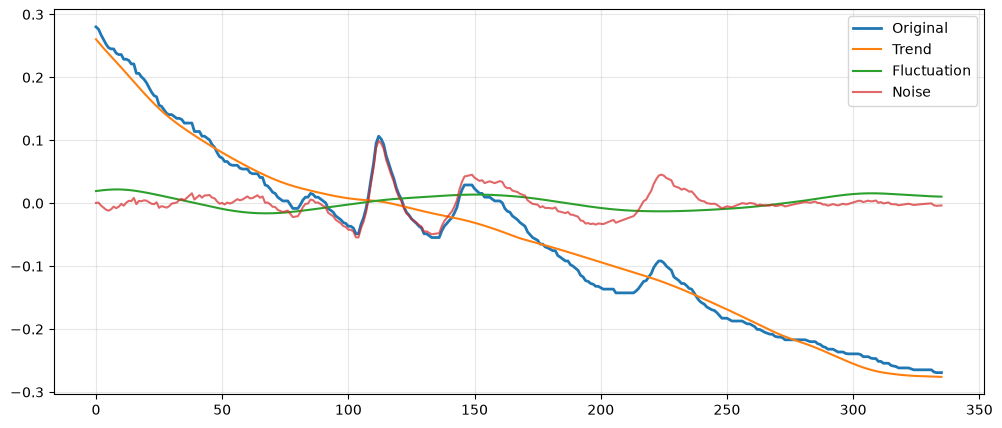

In [11]:
with torch.no_grad():
    X_ejemplo = normalizar_X(train_data[0]["X"])

    caudal_ejemplo = torch.from_numpy(
        X_ejemplo[None, :, 11]
    ).to(device)

    trend, fluct, noise = ssa_filtros(
        caudal_ejemplo,
        epsilon=epsilon_ssa,
        theta=theta_ssa,
        incluir_ruido=True,
    )

    reconstruccion = trend + fluct + noise

    error_ssa = torch.mean(
        torch.abs(reconstruccion - caudal_ejemplo)
    ).item()

print("Trend:", trend.shape)
print("Fluctuation:", fluct.shape)
print("Noise:", noise.shape)
print("MAE reconstrucción:", error_ssa)

plt.figure(figsize=(12, 5))
plt.plot(caudal_ejemplo[0].cpu(), label="Original", linewidth=2)
plt.plot(trend[0].cpu(), label="Trend")
plt.plot(fluct[0].cpu(), label="Fluctuation")
plt.plot(noise[0].cpu(), label="Noise", alpha=0.7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

## 7.2 BQA — también es determinista

En este notebook BQA no contiene parámetros entrenables.

Para una misma muestra siempre produce el mismo resultado:

\[
A = Softmax(X_{componente}X_{runoff}^{T})
\]

\[
Z = A^TX_{componente}+X_{componente}
\]

Por ello puede calcularse una sola vez junto con SSA y reutilizarse durante todas las épocas de E2.

La operación BQA se implementa en `asda.py` y se precalcula únicamente porque no contiene parámetros entrenables.


<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb">
<b>ESTRATEGIA COMPUTACIONAL</b> — No cambia el método del paper. Reduce tiempo de ejecución o evita trabajo repetido.
</div>

# 8. Precálculo y cache ASDA

Para reducir cálculos repetidos, precalculamos las transformaciones deterministas de SSA y BQA antes del entrenamiento:

```text
Caudal
  ↓
SSA
  ├── Trend ────────→ cache
  │      ↓
  │     BQA ────────→ Trend_BQA
  │
  └── Fluctuation ──→ cache
         ↓
        BQA ─────────→ Fluctuation_BQA
```

En E2 utilizamos `Trend_BQA` y `Fluctuation_BQA`, mientras que en E3 utilizamos `Trend` y `Fluctuation` antes de aplicar Dual Attention.

Este precálculo no incorpora el target futuro ni modifica el método evaluado; evita repetir las mismas operaciones deterministas en cada época.
El precálculo y la validación del cache se implementan en `soporte.py`.


<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb">
<b>ESTRATEGIA COMPUTACIONAL</b> — No cambia el método del paper. Reduce tiempo de ejecución o evita trabajo repetido.
</div>

### 8.1 Crear los precálculos

Esta celda es la única etapa donde se ejecuta SSA masivamente.

Si el cache ya existe y coincide con:

- índices;
- `ε`;
- `θ`;
- media/std del caudal;

se reutiliza automáticamente.

**Para la corrida final**, esta etapa puede tardar, pero se paga una sola vez.

In [12]:
cache_train = nombre_cache(cache_dir, "train")
cache_validation = nombre_cache(cache_dir, "validation")
cache_test = nombre_cache(cache_dir, "test")

parametros_cache = {
    "device": device,
    "media_caudal": media_x[11],
    "std_caudal": std_x[11],
    "epsilon": epsilon_ssa,
    "theta": theta_ssa,
    "batch_size_cache": batch_cache_ssa,
    "forzar_recalculo": forzar_recalculo_cache,
}

TIEMPOS["Cache train"] = precalcular_asda(
    train_data,
    indices_train,
    cache_train,
    **parametros_cache,
)

TIEMPOS["Cache validation"] = precalcular_asda(
    validation_data,
    indices_validation,
    cache_validation,
    **parametros_cache,
)

# Test se posterga hasta después de seleccionar el modelo.
TIEMPOS["Cache test"] = 0.0


Cache existente y válido: /home/winzcode/proyectos/rainfall-asda-forecasting/artifacts/cache/precalculo_train_full.h5
Cache existente y válido: /home/winzcode/proyectos/rainfall-asda-forecasting/artifacts/cache/precalculo_validation_full.h5


<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb">
<b>ESTRATEGIA COMPUTACIONAL</b> — No cambia el método del paper. Reduce tiempo de ejecución o evita trabajo repetido.
</div>

## 9. Dataset de entrenamiento con precálculos

Se crean dos vistas de los mismos datos:

- `DatosNormalizados`: usado por E1 Baseline.
- `DatosConPrecalculo`: usado por E2 y E3.

E2 y E3 leen **exactamente el mismo Trend/Fluctuation** desde disco.
La implementación de estas vistas se mantiene en `soporte.py`; el notebook conserva explícita la composición de los loaders para E1, E2 y E3.


In [13]:
baseline_train_loader = DataLoader(
    DatosNormalizados(
        train_data,
        indices_train,
        normalizar_X,
        normalizar_y,
    ),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

baseline_validation_loader = DataLoader(
    DatosNormalizados(
        validation_data,
        indices_validation,
        normalizar_X,
        normalizar_y,
    ),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

# E2 recibe salidas BQA desde cache.
asda_train_loader = DataLoader(
    DatosConPrecalculo(
        train_data,
        indices_train,
        cache_train,
        usar_bqa=True,
        normalizar_X=normalizar_X,
        normalizar_y=normalizar_y,
    ),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

asda_validation_loader = DataLoader(
    DatosConPrecalculo(
        validation_data,
        indices_validation,
        cache_validation,
        usar_bqa=True,
        normalizar_X=normalizar_X,
        normalizar_y=normalizar_y,
    ),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

# E3 recibe las señales antes de BQA.
ablation_train_loader = DataLoader(
    DatosConPrecalculo(
        train_data,
        indices_train,
        cache_train,
        usar_bqa=False,
        normalizar_X=normalizar_X,
        normalizar_y=normalizar_y,
    ),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

ablation_validation_loader = DataLoader(
    DatosConPrecalculo(
        validation_data,
        indices_validation,
        cache_validation,
        usar_bqa=False,
        normalizar_X=normalizar_X,
        normalizar_y=normalizar_y,
    ),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

print("Baseline train batches:", len(baseline_train_loader))
print("ASDA train batches:", len(asda_train_loader))
print("Ablación train batches:", len(ablation_train_loader))


Baseline train batches: 15875
ASDA train batches: 15875
Ablación train batches: 15875


<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

## 10. E1 — Baseline LSTM

Modelo base solicitado por el laboratorio.

No usa SSA ni atención:

`X [336,12] → LSTM → último hidden → Linear(48)`
La definición de `BaselineLSTM` se encuentra en `asda.py`; su arquitectura se mantiene sin cambios.


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

## 11. BQA — Back-Query Attention

BQA se ejecuta **antes de las LSTM**.

\[
A = Softmax(X_{componente}X_{runoff}^{T})
\]

\[
Z = A^TX_{componente} + X_{componente}
\]

La conexión residual también se conserva.
BQA forma parte de `asda.py` y mantiene la conexión residual descrita arriba.


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

## 12. TSA — Trans Self-Attention

Se conserva la secuencia conceptual del paper:

```text
Trend feature + Fluctuation feature
        ↓
      fusión
        ↓
 residual con runoff
        ↓
 normalización
        ↓
proyección 336 → 48
        ↓
      Q / K / V
        ↓
     atención
        ↓
normalización inversa
        ↓
      salida
```

La implementación es deliberadamente compacta para mantener el objetivo académico.
`TSAAdaptado` se mantiene en `asda.py`; el notebook conserva la secuencia conceptual necesaria para interpretar el paper.


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

<div style="border-left:6px solid #16a34a;padding:8px 12px;background:#f0fdf4">
<b>ADAPTACIÓN LAB2</b> — Cambio necesario para aplicar el método al dataset y al horizonte del laboratorio.
</div>

## 13. ASDA adaptado

**Del paper se conserva:**

`SSA → BQA → dual LSTM → TSA`

**Adaptación LAB2:**

las 11 variables meteorológicas se concatenan con Trend y Fluctuation antes de cada LSTM.

**Estrategia computacional:**

`Trend` y `Fluctuation` llegan ya precalculados; la red no ejecuta SVD durante `forward()`.
La clase `ASDA` está definida en `asda.py`; E2 y E3 modifican únicamente el uso de Dual Attention según el diseño experimental.


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

## 14. RSD Loss y ejecución wavefront

Conservamos la función de pérdida propuesta en el paper:

\[
L_{RSD}=\lambda_1RMSE+\lambda_2softDTW
\]

RMSE controla la diferencia de magnitud y soft-DTW incorpora similitud de forma temporal entre la predicción y la observación.

Para mantener la misma recurrencia de soft-DTW con menor costo computacional, procesamos en paralelo las celdas pertenecientes a una misma antidiagonal. De esta manera reducimos el trabajo secuencial en Python de `48×48 = 2304` posiciones a 95 antidiagonales vectorizadas en GPU.

La optimización modifica la forma de ejecutar el cálculo, pero no la definición matemática de RSD ni de soft-DTW.
La implementación de RSD Loss y soft-DTW wavefront se mantiene en `asda.py`; los pesos de la pérdida permanecen visibles en la configuración del notebook.


In [14]:
def perdida_rsd(y_pred, y_real):
    return rsd_loss(
        y_pred,
        y_real,
        lambda_rmse=lambda_rmse,
        lambda_soft_dtw=lambda_soft_dtw,
        gamma=gamma_soft_dtw,
    )


<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb">
<b>ESTRATEGIA COMPUTACIONAL</b> — No cambia el método del paper. Reduce tiempo de ejecución o evita trabajo repetido.
</div>

### 14.1 Validación de equivalencia

Para no optimizar a ciegas, se compara una única vez la versión wavefront contra la implementación secuencial anterior usando una secuencia pequeña.

Si los valores coinciden, seguimos usando únicamente la versión paralela durante el entrenamiento.


In [15]:
_prueba_pred = torch.tensor(
    [[0.0, 0.5, 1.0, 0.7]],
    dtype=torch.float32,
    device=device,
)

_prueba_real = torch.tensor(
    [[0.0, 0.4, 0.9, 0.8]],
    dtype=torch.float32,
    device=device,
)

valor_original = soft_dtw_referencia(
    _prueba_pred,
    _prueba_real,
    gamma=gamma_soft_dtw,
)

valor_paralelo = soft_dtw(
    _prueba_pred,
    _prueba_real,
    gamma=gamma_soft_dtw,
)

assert torch.allclose(
    valor_original,
    valor_paralelo,
    atol=1e-6,
)

print("soft-DTW original :", valor_original.item())
print("soft-DTW wavefront:", valor_paralelo.item())
print("Equivalencia matemática: OK")


soft-DTW original : -0.11259336024522781
soft-DTW wavefront: -0.11259336024522781
Equivalencia matemática: OK


<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

## 15. Métricas

El paper evalúa con:

- RMSE;
- MAE;
- NSE;
- KGE;
- PBIAS.

Las métricas se calculan en `mm/h`, después de desnormalizar. El cálculo operativo se centraliza en `soporte.py`.

**Nota sobre PBIAS.** La función implementada en `soporte.py` calcula la media del error porcentual por observación, excluyendo únicamente valores reales con magnitud menor o igual a `1e-8`. No debe asumirse que sus valores son directamente comparables con una variante agregada de PBIAS; además, puede ser muy sensible cuando el caudal real se aproxima a cero.

<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb"><b>ESTRATEGIA COMPUTACIONAL</b> — Optimización de ejecución. No cambia el método ASDA.</div>

<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff"><b>RÚBRICA LAB2</b> — Evidencia experimental requerida para la entrega.</div>

## 16. Entrenamiento, validación y Early Stopping

Cada época ejecuta:

```text
TRAIN → actualizar pesos
  ↓
VALIDATION → calcular RMSE
  ↓
¿mejoró?
 ├─ Sí → guardar mejor estado
 └─ No → contador +1
              ↓
         patience = 2
              ↓
            STOP
```

Early stopping es una decisión del LAB, no del paper. Evita épocas sin mejora de generalización y reduce el costo computacional.

El ciclo de entrenamiento y early stopping se encuentra en `soporte.py`; la configuración y los resultados permanecen visibles en el notebook.


<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

# 17. Experimentos

## E1 — Baseline

Referencia simple solicitada por el LAB.

In [16]:
_t0 = time.perf_counter()

baseline = BaselineLSTM(
    hidden_size=hidden_size,
).to(device)

historial_baseline, metricas_baseline, resumen_baseline = entrenar(
    baseline,
    baseline_train_loader,
    baseline_validation_loader,
    max_epochs=max_epochs_baseline,
    nombre="E1 Baseline",
    perdida=nn.MSELoss(),
    device=device,
    desnormalizar_y=desnormalizar_y,
    patience=patience,
    min_epochs=min_epochs,
)

TIEMPOS["E1 Baseline"] = time.perf_counter() - _t0

torch.save(
    {
        "model_state_dict": baseline.state_dict(),
        "metricas": metricas_baseline,
        "resumen": resumen_baseline,
    },
    checkpoints_dir / "E1_baseline_best.pt",
)


E1 Baseline | época 1/10 | loss=0.4076 | RMSE val=0.10373 mm/h | train=2.12 min | val=0.12 min | ✓ mejor
E1 Baseline | época 2/10 | loss=0.3834 | RMSE val=0.10551 mm/h | train=1.98 min | val=0.11 min | sin mejora 1/2
E1 Baseline | época 3/10 | loss=0.3772 | RMSE val=0.10423 mm/h | train=1.98 min | val=0.11 min | sin mejora 2/2
EARLY STOPPING → E1 Baseline: mejor época=1, RMSE=0.10373


<div style="border-left:6px solid #2563eb;padding:8px 12px;background:#eff6ff">
<b>PAPER</b> — Este bloque corresponde directamente a una idea o componente propuesto por Tian et al. (ASDA).
</div>

<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

## E2 — ASDA

Método principal:

`Adaptive SSA(cache) → BQA → dual LSTM → TSA`

Entrena con RSD Loss.

In [17]:
_t0 = time.perf_counter()

asda = ASDA(
    hidden_size=hidden_size,
    con_atencion=True,
    bqa_precalculado=True,
).to(device)

historial_asda, metricas_asda, resumen_asda = entrenar(
    asda,
    asda_train_loader,
    asda_validation_loader,
    max_epochs=max_epochs_asda,
    nombre="E2 ASDA",
    perdida=perdida_rsd,
    device=device,
    desnormalizar_y=desnormalizar_y,
    patience=patience,
    min_epochs=min_epochs,
)

TIEMPOS["E2 ASDA"] = time.perf_counter() - _t0

torch.save(
    {
        "model_state_dict": asda.state_dict(),
        "metricas": metricas_asda,
        "resumen": resumen_asda,
    },
    checkpoints_dir / "E2_asda_best.pt",
)


E2 ASDA | época 1/6 | loss=3.3849 | RMSE val=0.15339 mm/h | train=25.48 min | val=0.19 min | ✓ mejor
E2 ASDA | época 2/6 | loss=3.9573 | RMSE val=0.13679 mm/h | train=25.14 min | val=0.15 min | ✓ mejor
E2 ASDA | época 3/6 | loss=4.1836 | RMSE val=0.13549 mm/h | train=24.45 min | val=0.15 min | ✓ mejor
E2 ASDA | época 4/6 | loss=3.8287 | RMSE val=0.14368 mm/h | train=24.75 min | val=0.15 min | sin mejora 1/2
E2 ASDA | época 5/6 | loss=3.5671 | RMSE val=0.17771 mm/h | train=24.38 min | val=0.15 min | sin mejora 2/2
EARLY STOPPING → E2 ASDA: mejor época=3, RMSE=0.13549


<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

## E3 — Ablación sin Dual Attention

Conserva:

- el mismo cache SSA;
- las mismas ramas LSTM;
- la misma RSD Loss.

Elimina BQA y TSA.

Por tanto E2 vs E3 mide el aporte de **Dual Attention**.

In [18]:
_t0 = time.perf_counter()

asda_sin_atencion = ASDA(
    hidden_size=hidden_size,
    con_atencion=False,
).to(device)

historial_ablation, metricas_ablation, resumen_ablation = entrenar(
    asda_sin_atencion,
    ablation_train_loader,
    ablation_validation_loader,
    max_epochs=max_epochs_asda,
    nombre="E3 Sin atención",
    perdida=perdida_rsd,
    device=device,
    desnormalizar_y=desnormalizar_y,
    patience=patience,
    min_epochs=min_epochs,
)

TIEMPOS["E3 Ablación"] = time.perf_counter() - _t0

torch.save(
    {
        "model_state_dict": asda_sin_atencion.state_dict(),
        "metricas": metricas_ablation,
        "resumen": resumen_ablation,
    },
    checkpoints_dir / "E3_ablation_best.pt",
)


E3 Sin atención | época 1/6 | loss=2.1682 | RMSE val=0.11763 mm/h | train=24.68 min | val=0.14 min | ✓ mejor
E3 Sin atención | época 2/6 | loss=1.7353 | RMSE val=0.11781 mm/h | train=24.28 min | val=0.14 min | sin mejora 1/2
E3 Sin atención | época 3/6 | loss=1.5744 | RMSE val=0.11498 mm/h | train=24.40 min | val=0.14 min | ✓ mejor
E3 Sin atención | época 4/6 | loss=1.4927 | RMSE val=0.11498 mm/h | train=24.49 min | val=0.14 min | sin mejora 1/2
E3 Sin atención | época 5/6 | loss=1.4198 | RMSE val=0.11526 mm/h | train=24.31 min | val=0.14 min | sin mejora 2/2
EARLY STOPPING → E3 Sin atención: mejor época=3, RMSE=0.11498


<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

## 18. Comparación de resultados

Comparamos E1, E2 y E3 utilizando las mismas particiones de datos y las mismas métricas de validation.

La comparación se interpreta a partir de los resultados obtenidos en nuestro dataset. El objetivo no es reproducir numéricamente los resultados del paper, sino evaluar si los componentes adaptados mantienen su aporte bajo las condiciones del Laboratorio 2.

,RMSE,MAE,NSE,KGE,PBIAS
E1 Baseline LSTM,0.10373,0.02548,0.63455,0.69933,1559.10095
E2 ASDA,0.13549,0.04234,0.37658,0.53963,1586.38953
E3 ASDA sin atención,0.11498,0.02859,0.55101,0.67419,1290.85034


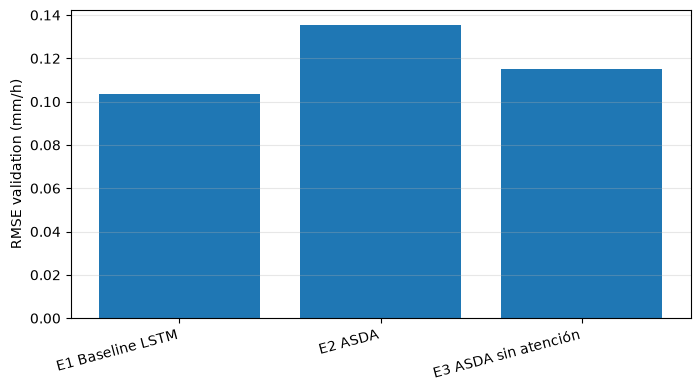

In [19]:
resultados = pd.DataFrame(
    [
        metricas_baseline,
        metricas_asda,
        metricas_ablation,
    ],
    index=[
        "E1 Baseline LSTM",
        "E2 ASDA",
        "E3 ASDA sin atención",
    ],
)

display(resultados.round(5))

plt.figure(figsize=(8, 4))
plt.bar(
    resultados.index,
    resultados["RMSE"],
)
plt.ylabel("RMSE validation (mm/h)")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb"><b>ESTRATEGIA COMPUTACIONAL</b> — Optimización de ejecución. No cambia el método ASDA.</div>

### 18.1 Resumen del entrenamiento

Esta tabla muestra cuántas épocas se ejecutaron realmente y cuál fue la mejor según RMSE de validation.


In [20]:
resumen_entrenamiento = pd.DataFrame(
    [resumen_baseline, resumen_asda, resumen_ablation]
)

display(
    resumen_entrenamiento[
        [
            "modelo",
            "epocas_ejecutadas",
            "mejor_epoca",
            "detenido_antes",
            "mejor_rmse",
            "train_min",
            "validation_min",
        ]
    ].round(4)
)

,modelo,epocas_ejecutadas,mejor_epoca,detenido_antes,mejor_rmse,train_min,validation_min
0,E1 Baseline,3,1,True,0.1037,6.0771,0.3324
1,E2 ASDA,5,3,True,0.1355,124.2035,0.7859
2,E3 Sin atención,5,3,True,0.1150,122.1564,0.7014


<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

## 19. Análisis de errores y horizonte de predicción

Analizamos el comportamiento del modelo seleccionado desde dos perspectivas.

Primero calculamos el MAE para cada uno de los **48 horizontes futuros**, lo que permite observar cómo cambia el error conforme nos alejamos del último instante conocido.

Luego seleccionamos, dentro de validation, el caso con el mayor pico real y comparamos su curva observada con la curva pronosticada. Este segundo gráfico representa directamente la **predicción de las próximas 48 horas**: contiene las 48 salidas generadas por el modelo frente a las 48 observaciones reales del mismo horizonte.

Con esta visualización adaptamos al horizonte del LAB el tipo de comparación temporal utilizado en el paper para analizar las curvas de predicción multi-step.

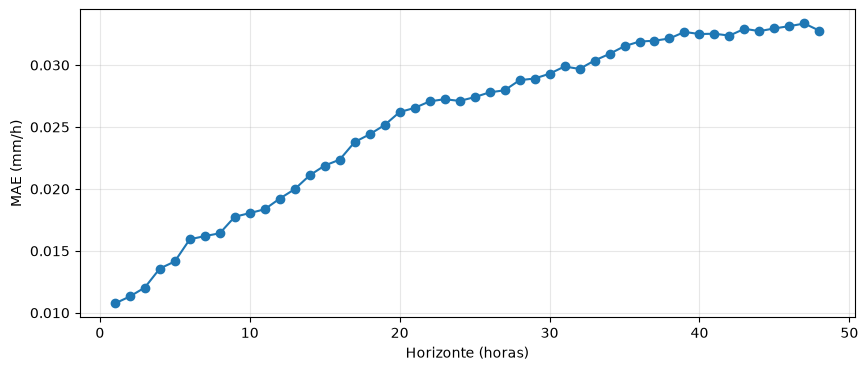

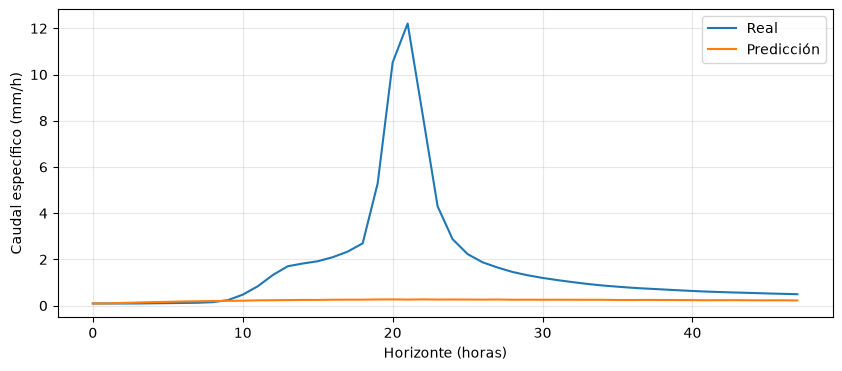

Mejor modelo por RMSE: E1 Baseline LSTM


In [21]:
_t0 = time.perf_counter()

modelos = {
    "E1 Baseline LSTM": (
        baseline,
        baseline_validation_loader,
    ),
    "E2 ASDA": (
        asda,
        asda_validation_loader,
    ),
    "E3 ASDA sin atención": (
        asda_sin_atencion,
        asda_validation_loader,
    ),
}

mejor_nombre = resultados["RMSE"].idxmin()
mejor_modelo, mejor_loader = modelos[mejor_nombre]

y_real, y_pred = predecir(
    mejor_modelo,
    mejor_loader,
    device,
    desnormalizar_y,
)

mae_horizonte = np.mean(
    np.abs(y_pred - y_real),
    axis=0,
)

plt.figure(figsize=(10, 4))
plt.plot(
    np.arange(1, 49),
    mae_horizonte,
    marker="o",
)
plt.xlabel("Horizonte (horas)")
plt.ylabel("MAE (mm/h)")
plt.grid(alpha=0.3)
plt.show()

indice_pico = np.argmax(
    y_real.max(axis=1)
)

plt.figure(figsize=(10, 4))
plt.plot(y_real[indice_pico], label="Real")
plt.plot(y_pred[indice_pico], label="Predicción")
plt.xlabel("Horizonte (horas)")
plt.ylabel("Caudal específico (mm/h)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Mejor modelo por RMSE:", mejor_nombre)

TIEMPOS["Análisis"] = time.perf_counter() - _t0

<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff"><b>RÚBRICA LAB2</b> — Evidencia experimental requerida para la entrega.</div>

### 19.1 Interpretación final de resultados

En validation obtuvimos el mejor desempeño global con **E1 Baseline LSTM**, con `RMSE=0.10373`, `MAE=0.02548`, `NSE=0.63455` y `KGE=0.69933`.

El modelo **E2 ASDA** alcanzó `RMSE=0.13549`, `MAE=0.04234`, `NSE=0.37658` y `KGE=0.53963`. Bajo nuestra adaptación y dataset, ASDA completo no superó al baseline.

La ablación **E3 ASDA sin atención** obtuvo `RMSE=0.11498`, `MAE=0.02859`, `NSE=0.55101` y `KGE=0.67419`. E3 superó a E2 en las principales métricas, por lo que en este experimento la incorporación de BQA+TSA no produjo una mejora frente a la arquitectura sin Dual Attention.

El análisis por horizonte muestra un incremento progresivo del MAE: parte aproximadamente de `0.011 mm/h` en los primeros pasos y se aproxima a `0.033 mm/h` hacia el final de las 48 horas. Esto evidencia una pérdida gradual de precisión conforme aumenta el horizonte de pronóstico.

En el caso de validation con el mayor pico, el valor real supera los `12 mm/h`, mientras que la predicción del baseline permanece muy por debajo del pico observado. Aunque E1 presenta las mejores métricas agregadas, este caso evidencia una limitación relevante para representar eventos extremos.

Los valores de PBIAS resultaron muy elevados en los tres modelos. En nuestro cálculo, esta métrica utiliza error relativo por observación y se vuelve inestable cuando el caudal real se aproxima a cero; por ello la interpretamos junto con RMSE, MAE, NSE y KGE y no como criterio aislado de selección.

<div style="border-left:6px solid #16a34a;padding:8px 12px;background:#f0fdf4"><b>ADAPTACIÓN LAB2</b> — Ajuste necesario para aplicar ASDA al dataset y objetivo del laboratorio.</div>

<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff"><b>RÚBRICA LAB2</b> — Evidencia experimental requerida para la entrega.</div>

## 20. Diferencias y limitaciones respecto al paper

1. El paper estudia runoff urbano en una zona, resolución temporal y horizonte distintos a los del LAB.
2. Nuestro dataset contiene múltiples cuencas y 11 variables meteorológicas adicionales.
3. Aplicamos Adaptive SSA únicamente sobre las 336 horas históricas de caudal de cada muestra; no descomponemos la serie completa y no utilizamos las 48 horas futuras durante SSA, evitando el mecanismo de data leakage señalado por el paper.
4. Incorporamos la meteorología como contexto de las dos ramas LSTM.
5. Conservamos la lógica central de TSA mediante una implementación académica compacta.
6. Omitimos KW sampling y TPE porque no forman parte del objetivo experimental requerido en el laboratorio.
7. Precalculamos SSA y BQA porque son deterministas en nuestra implementación; esta decisión reduce costo sin introducir información futura.
8. Conservamos la recurrencia de soft-DTW y la ejecutamos mediante wavefront por antidiagonales.
9. Utilizamos early stopping como estrategia propia del LAB; no corresponde al procedimiento de entrenamiento reportado por el paper.
10. Los resultados numéricos del paper no son directamente comparables con los obtenidos en este dataset.
11. PBIAS presenta inestabilidad cuando existen observaciones cercanas a cero.
12. La comparación E1 vs E2 contrasta dos soluciones completas y no permite atribuir la diferencia de desempeño a un único componente. La comparación E2 vs E3 constituye una ablación más controlada para analizar específicamente el aporte de Dual Attention.
13. Las métricas agregadas no reflejan por completo el desempeño en eventos extremos; el caso de mayor pico muestra una subestimación importante aun cuando E1 obtiene el mejor resultado global.

<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Bloque incluido para demostrar experimentalmente lo solicitado por el docente.
</div>

<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb">
<b>ESTRATEGIA COMPUTACIONAL</b> — No cambia el método del paper. Reduce tiempo de ejecución o evita trabajo repetido.
</div>

## 21. Predicciones de test

Seleccionamos el modelo utilizando exclusivamente las métricas de validation. E1 Baseline LSTM obtuvo el menor RMSE y fue el modelo utilizado para generar las predicciones finales sobre las 27,983 muestras de test.

La salida contiene 48 valores de caudal pronosticado por muestra, correspondientes a las próximas 48 horas, y se almacenó en `predicciones_lab2_ASDA_FINAL.csv`.
La inferencia de test utiliza una única función de soporte para los tres modelos y conserva la selección basada exclusivamente en validation.


In [36]:
# El precálculo de test se paga solo si el modelo elegido lo necesita.
if mejor_nombre != "E1 Baseline LSTM":
    TIEMPOS["Cache test"] = precalcular_asda(
        test_data,
        indices_test,
        cache_test,
        **parametros_cache,
    )

_t0 = time.perf_counter()

if mejor_nombre == "E1 Baseline LSTM":
    test_loader = DataLoader(
        DatosNormalizados(
            test_data,
            indices_test,
            normalizar_X,
            normalizar_y,
            con_y=False,
        ),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

else:
    usar_bqa_test = mejor_nombre == "E2 ASDA"

    test_loader = DataLoader(
        DatosConPrecalculo(
            test_data,
            indices_test,
            cache_test,
            usar_bqa=usar_bqa_test,
            normalizar_X=normalizar_X,
            normalizar_y=normalizar_y,
            con_y=False,
        ),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

_, predicciones_test = predecir_test(
    mejor_modelo,
    test_loader,
    device,
    desnormalizar_y,
)
ids_test = np.asarray(indices_test, dtype=np.int64)

assert predicciones_test.shape == (
    len(indices_test),
    48,
)

assert np.isfinite(predicciones_test).all()

columnas = [
    f"horizon_{hora}"
    for hora in range(1, 49)
]

salida = pd.DataFrame(
    predicciones_test.astype(np.float32),
    columns=columnas,
)

salida.insert(
    0,
    "Id",
    ids_test,
)

nombre_salida = str(outputs_dir / "predicciones_lab2_ASDA_FINAL.csv")

salida.to_csv(
    nombre_salida,
    index=False,
)

TIEMPOS["Inferencia test"] = time.perf_counter() - _t0

print("Modelo seleccionado:", mejor_nombre)
print("Predicciones:", predicciones_test.shape)
print("Archivo:", nombre_salida)

Modelo seleccionado: E1 Baseline LSTM
Predicciones: (27983, 48)
Archivo: /home/winzcode/proyectos/rainfall-asda-forecasting/outputs/predicciones_lab2_ASDA_FINAL.csv


# 22. Trazabilidad de componentes

| Bloque | Origen |
|---|---|
| Adaptive SSA | **PAPER** |
| `ε`, `θ` y filtros Trend/Fluctuation/Noise | **PAPER** |
| BQA | **PAPER** |
| Dual LSTM | **PAPER** |
| TSA | **PAPER**, implementación académica compacta |
| RSD Loss | **PAPER** |
| 11 variables meteorológicas | **ADAPTACIÓN LAB2** |
| Entrada 336 h / salida 48 h | **ADAPTACIÓN LAB2** |
| Z-score multivariado | **ADAPTACIÓN LAB2** |
| Cache de Trend/Fluctuation/BQA | **ESTRATEGIA COMPUTACIONAL** |
| soft-DTW wavefront | **ESTRATEGIA COMPUTACIONAL** |
| Early stopping | **ESTRATEGIA COMPUTACIONAL** |
| Baseline E1 | **RÚBRICA LAB2** |
| Ablación E3 | **RÚBRICA LAB2 / PAPER** |
| Métricas y análisis de errores | **RÚBRICA LAB2** |
| Inferencia test | **RÚBRICA LAB2** |

El cache no modifica la información utilizada por ASDA. Calculamos SSA una sola vez sobre cada ventana histórica de 336 horas y almacenamos sus componentes. Para E2 almacenamos además la salida determinista de BQA, mientras que E3 consume `Trend` y `Fluctuation` antes de Dual Attention. En ningún caso utilizamos el target futuro durante el precálculo.

<div style="border-left:6px solid #d97706;padding:8px 12px;background:#fffbeb"><b>ESTRATEGIA COMPUTACIONAL</b> — Optimización de ejecución. No cambia el método ASDA.</div>

# 23. Resumen de ejecución final

Se registran los tiempos reales de precálculo, entrenamiento, análisis e inferencia, además de las épocas efectivamente utilizadas por early stopping.


In [23]:
TIEMPOS["TOTAL NOTEBOOK"] = time.perf_counter() - INICIO_NOTEBOOK

tabla_tiempos = pd.DataFrame(
    [
        {"Fase": "Estadísticas train", "Minutos": TIEMPOS.get("Estadísticas train", 0)/60},
        {"Fase": "Cache train", "Minutos": TIEMPOS.get("Cache train", 0)/60},
        {"Fase": "Cache validation", "Minutos": TIEMPOS.get("Cache validation", 0)/60},
        {"Fase": "E1 Baseline", "Minutos": TIEMPOS.get("E1 Baseline", 0)/60},
        {"Fase": "E2 ASDA", "Minutos": TIEMPOS.get("E2 ASDA", 0)/60},
        {"Fase": "E3 Ablación", "Minutos": TIEMPOS.get("E3 Ablación", 0)/60},
        {"Fase": "Análisis", "Minutos": TIEMPOS.get("Análisis", 0)/60},
        {"Fase": "Cache test", "Minutos": TIEMPOS.get("Cache test", 0)/60},
        {"Fase": "Inferencia test", "Minutos": TIEMPOS.get("Inferencia test", 0)/60},
    ]
)

display(tabla_tiempos.round(2))

print("ÉPOCAS EFECTIVAS")
print(f"E1: {resumen_baseline['epocas_ejecutadas']} (mejor={resumen_baseline['mejor_epoca']})")
print(f"E2: {resumen_asda['epocas_ejecutadas']} (mejor={resumen_asda['mejor_epoca']})")
print(f"E3: {resumen_ablation['epocas_ejecutadas']} (mejor={resumen_ablation['mejor_epoca']})")

print()
print("MODELO SELECCIONADO:", mejor_nombre)
print("ARCHIVO TEST:", nombre_salida)
print(f"TIEMPO TOTAL REAL: {TIEMPOS['TOTAL NOTEBOOK']/3600:.2f} horas")

,Fase,Minutos
0,Estadísticas train,0.90
1,Cache train,0.00
2,Cache validation,0.00
3,E1 Baseline,6.54
4,E2 ASDA,125.15
5,E3 Ablación,123.00
6,Análisis,0.10
7,Cache test,0.00
8,Inferencia test,0.12


ÉPOCAS EFECTIVAS
E1: 3 (mejor=1)
E2: 5 (mejor=3)
E3: 5 (mejor=3)

MODELO SELECCIONADO: E1 Baseline LSTM
ARCHIVO TEST: /home/winzcode/proyectos/rainfall-asda-forecasting/outputs/predicciones_lab2_ASDA_FINAL.csv
TIEMPO TOTAL REAL: 4.26 horas


# 24. Validación de la ejecución final

La corrida final se completó con el dataset completo:

- Train: **254,000** muestras.
- Validation: **18,142** muestras.
- Test: **27,983** muestras.
- Las estadísticas de normalización se calcularon exclusivamente con train.
- Se reutilizaron los caches SSA+BQA de train y validation; no se recalcularon en esta corrida. El cache de test no fue necesario porque E1 Baseline LSTM resultó seleccionado.
- Se verificó la equivalencia de soft-DTW wavefront frente a la implementación secuencial.
- E1, E2 y E3 se entrenaron con seguimiento de RMSE de validation y early stopping.
- Se obtuvieron RMSE, MAE, NSE, KGE y PBIAS para los tres experimentos.
- Se analizó el error para los 48 horizontes futuros.
- Se comparó la curva real y la predicción de 48 horas para el caso con mayor pico de validation.
- El modelo final se seleccionó únicamente con validation.
- Se generó `predicciones_lab2_ASDA_FINAL.csv` para las 27,983 muestras de test.
- Se almacenaron los checkpoints de E1, E2 y E3.
- El tiempo total de esta ejecución fue **4.26 horas**.

La implementación final mantiene el flujo central de ASDA y adapta el método al problema multivariado y multi-step del laboratorio. En esta corrida, reutilizar los caches evitó repetir el precálculo; soft-DTW wavefront y early stopping redujeron el costo del entrenamiento.

<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff"><b>RÚBRICA LAB2</b> — Evidencia experimental requerida para la entrega.</div>

# 25. Síntesis de hallazgos

1. **E1 Baseline LSTM obtuvo el mejor resultado global** en validation con `RMSE=0.10373`.
2. **E2 ASDA no superó al baseline** bajo la adaptación realizada para este dataset.
3. **E3 sin Dual Attention superó a E2**, por lo que BQA+TSA no aportaron mejora en las condiciones de nuestro experimento.
4. El error aumentó progresivamente a medida que avanzó el horizonte de 48 horas.
5. El caso con mayor pico mostró una subestimación severa del evento extremo, aun cuando el baseline obtuvo las mejores métricas agregadas.
6. E1 alcanzó su mejor estado en la época 1; E2 y E3 alcanzaron su mejor estado en la época 3. Early stopping evitó continuar con épocas que no mejoraban validation.
7. La implementación evitó el data leakage señalado por el paper al aplicar SSA únicamente sobre las 336 horas históricas de cada muestra y excluir las 48 horas futuras del precálculo.
8. En esta ejecución, los caches SSA+BQA existentes se reutilizaron y el notebook terminó en **4.26 horas**.

<div style="border-left:6px solid #7c3aed;padding:8px 12px;background:#f5f3ff">
<b>RÚBRICA LAB2</b> — Evaluación final del modelo seleccionado sobre el conjunto de test.
</div>

# 26. Evaluación final sobre `test_targets.csv`

La selección del modelo se mantiene exactamente como fue realizada en validation. Esta sección utiliza `test_targets.csv` únicamente para medir el desempeño final del modelo ya seleccionado sobre las **27,983 muestras de test**.

**Nota metodológica.** El conjunto de test se utiliza únicamente para evaluación final. La selección del modelo, early stopping y cualquier decisión de entrenamiento se realizaron previamente utilizando train y validation.

**Correspondencia de muestras.** El `Id` de `test_targets.csv` corresponde directamente al índice de la muestra en `test.h5`, según confirmación del docente. Aun con esta correspondencia, la evaluación se alinea mediante un `merge` explícito por `Id` y no por la posición de las filas.

## 26.1 Carga de targets y predicciones

Se cargan los valores reales de `test_targets.csv` y el archivo de predicciones generado previamente por el modelo seleccionado. No se ejecuta entrenamiento ni se modifica el proceso de selección del modelo.

In [37]:
targets_df = pd.read_csv(PROJECT_ROOT / "data" / "test_targets.csv")
pred_df = pd.read_csv(nombre_salida)

print("Targets:", targets_df.shape)
print("Predicciones:", pred_df.shape)

display(targets_df.head(3))

Targets: (27983, 49)
Predicciones: (27983, 49)


,Id,q_01,q_02,q_03,q_04,q_05,q_06,q_07,q_08,q_09,...,q_39,q_40,q_41,q_42,q_43,q_44,q_45,q_46,q_47,q_48
0,0,0.180350,0.179222,0.178471,0.178471,0.176968,0.176592,0.175841,0.175089,0.174338,...,0.155176,0.155927,0.155176,0.153297,0.153297,0.153297,0.152921,0.152921,0.151381,0.150479
1,1,0.018976,0.018759,0.018790,0.018512,0.018574,0.019131,0.019193,0.019069,0.019317,...,0.018202,0.018883,0.018667,0.019100,0.018481,0.018481,0.018140,0.018078,0.018140,0.018078
2,2,0.002699,0.002767,0.002847,0.002885,0.003004,0.003123,0.003199,0.003344,0.003505,...,0.010981,0.011130,0.011257,0.011321,0.011406,0.011490,0.011512,0.011533,0.011533,0.011533


## 26.2 Validación de estructura

El archivo de targets debe contener una columna `Id` y exactamente 48 valores futuros de caudal específico, desde `q_01` hasta `q_48`. También se verifica que cada `Id` aparezca una sola vez.

In [41]:
columnas_target = [
    f"q_{hora:02d}"
    for hora in range(1, 49)
]

columnas_pred = [
    f"horizon_{hora}"
    for hora in range(1, 49)
]

assert len(targets_df) == 27_983, (
    f"Se esperaban 27,983 targets y se encontraron {len(targets_df):,}."
)
assert "Id" in targets_df.columns
assert all(columna in targets_df.columns for columna in columnas_target)
assert targets_df["Id"].is_unique, "Existen Id duplicados en test_targets.csv."

assert len(pred_df) == 27_983, (
    f"Se esperaban 27,983 predicciones y se encontraron {len(pred_df):,}."
)
assert "Id" in pred_df.columns
assert all(columna in pred_df.columns for columna in columnas_pred)
assert pred_df["Id"].is_unique, "Existen Id duplicados en las predicciones."

print("Estructura de targets: OK")
print("Estructura de predicciones: OK")
print("Targets por muestra:", len(columnas_target))
print("Predicciones por muestra:", len(columnas_pred))

Estructura de targets: OK
Estructura de predicciones: OK
Targets por muestra: 48
Predicciones por muestra: 48


## 26.3 Correspondencia uno-a-uno por `Id`

La correspondencia entre predicciones y valores reales se valida por identificador. El `merge` utiliza `validate="one_to_one"` para impedir asociaciones duplicadas y se comprueba que ambos archivos contengan exactamente el mismo conjunto de `Id`.

In [42]:
assert set(pred_df["Id"]) == set(targets_df["Id"]), (
    "Los Id de predicciones y test_targets.csv no coinciden exactamente."
)

evaluacion_test_df = (
    pred_df[["Id", *columnas_pred]]
    .merge(
        targets_df[["Id", *columnas_target]],
        on="Id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("Id")
    .reset_index(drop=True)
)

assert len(evaluacion_test_df) == 27_983
assert np.array_equal(
    evaluacion_test_df["Id"].to_numpy(),
    np.arange(27_983),
), "Los Id esperados deben cubrir exactamente el rango 0 ... 27,982."

print("Correspondencia uno-a-uno por Id: OK")
print("Muestras alineadas:", len(evaluacion_test_df))

Correspondencia uno-a-uno por Id: OK
Muestras alineadas: 27983


## 26.4 Matrices finales de evaluación

A partir del conjunto alineado se construyen dos matrices de dimensión `27,983 × 48`: una para las predicciones y otra para los valores reales. Antes de calcular métricas se verifica la ausencia de valores faltantes e infinitos.

In [43]:
y_pred_test = evaluacion_test_df[columnas_pred].to_numpy(dtype=np.float64)
y_real_test = evaluacion_test_df[columnas_target].to_numpy(dtype=np.float64)

assert y_pred_test.shape == (27_983, 48)
assert y_real_test.shape == (27_983, 48)

assert not np.isnan(y_pred_test).any(), "Las predicciones contienen NaN."
assert not np.isnan(y_real_test).any(), "Los targets contienen NaN."

assert np.isfinite(y_pred_test).all(), "Las predicciones contienen infinitos."
assert np.isfinite(y_real_test).all(), "Los targets contienen infinitos."

print("y_pred_test:", y_pred_test.shape)
print("y_real_test:", y_real_test.shape)
print("Integridad numérica: OK")

y_pred_test: (27983, 48)
y_real_test: (27983, 48)
Integridad numérica: OK


## 26.5 Métricas finales en TEST

Se utilizan las mismas métricas empleadas durante validation: **RMSE, MAE, NSE, KGE y PBIAS**. Las funciones se reutilizan desde el módulo de soporte; no se redefine la lógica de cálculo.

In [44]:
from soporte import kge, mae, nse, pbias, rmse

metricas_test = {
    "RMSE": rmse(y_real_test, y_pred_test),
    "MAE": mae(y_real_test, y_pred_test),
    "NSE": nse(y_real_test, y_pred_test),
    "KGE": kge(y_real_test, y_pred_test),
    "PBIAS": pbias(y_real_test, y_pred_test),
}

tabla_test = pd.DataFrame(
    [
        {
            "Dataset": "Test",
            "Modelo": mejor_nombre,
            **metricas_test,
        }
    ]
)

display(tabla_test.round(5))

,Dataset,Modelo,RMSE,MAE,NSE,KGE,PBIAS
0,Test,E1 Baseline LSTM,0.10226,0.02699,0.62624,0.70264,1651.69087


## 26.6 Validation vs TEST

La comparación se realiza únicamente para el modelo que ya había sido seleccionado mediante validation. Los resultados de test no intervienen en la selección del modelo ni modifican decisiones de entrenamiento.

La columna **Diferencia** se calcula como `Test - Validation`. Para RMSE y MAE, un aumento representa mayor error; para NSE y KGE, una disminución representa menor ajuste. PBIAS se interpreta junto con las demás métricas debido a su sensibilidad cuando el caudal real se aproxima a cero.

In [45]:
metricas_comparables = [
    "RMSE",
    "MAE",
    "NSE",
    "KGE",
    "PBIAS",
]

validation_seleccionado = resultados.loc[
    mejor_nombre,
    metricas_comparables,
]

comparacion_validation_test = pd.DataFrame(
    {
        "Métrica": metricas_comparables,
        "Validation": [
            validation_seleccionado[metrica]
            for metrica in metricas_comparables
        ],
        "Test": [
            metricas_test[metrica]
            for metrica in metricas_comparables
        ],
    }
)

comparacion_validation_test["Diferencia"] = (
    comparacion_validation_test["Test"]
    - comparacion_validation_test["Validation"]
)

display(comparacion_validation_test.round(5))

,Métrica,Validation,Test,Diferencia
0,RMSE,0.10373,0.10226,-0.00147
1,MAE,0.02548,0.02699,0.00151
2,NSE,0.63455,0.62624,-0.00831
3,KGE,0.69933,0.70264,0.00331
4,PBIAS,1559.10095,1651.69087,92.58992


## 26.7 MAE por horizonte en TEST

El error absoluto medio se calcula de forma independiente para cada una de las **48 horas futuras**, permitiendo observar si la precisión cambia a medida que aumenta el horizonte de pronóstico.

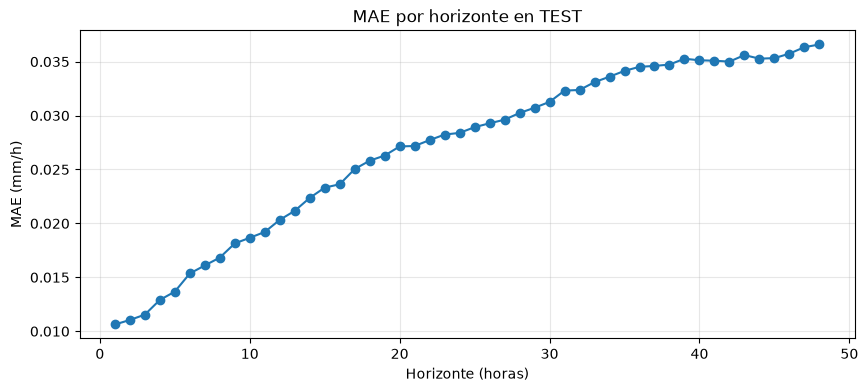

In [46]:
mae_horizonte_test = np.mean(
    np.abs(y_pred_test - y_real_test),
    axis=0,
)

plt.figure(figsize=(10, 4))
plt.plot(
    np.arange(1, 49),
    mae_horizonte_test,
    marker="o",
)
plt.xlabel("Horizonte (horas)")
plt.ylabel("MAE (mm/h)")
plt.title("MAE por horizonte en TEST")
plt.grid(alpha=0.3)
plt.show()

## 26.8 Real vs predicción — caso con mayor pico real en TEST

Se identifica la muestra cuyo horizonte futuro contiene el mayor pico real de caudal específico. La comparación muestra las **próximas 48 horas** de esa muestra y permite observar directamente la capacidad del modelo para representar un evento extremo.

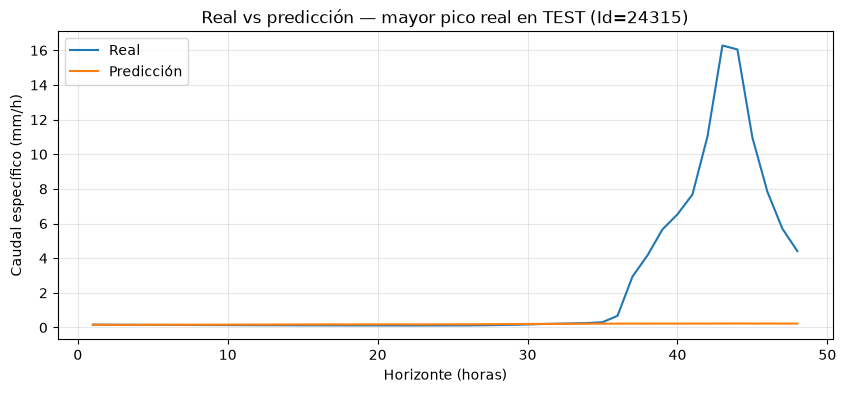

Id del caso: 24315
Pico real: 16.27951 mm/h
Pico predicho: 0.23015 mm/h


In [47]:
indice_pico_test = np.argmax(
    y_real_test.max(axis=1)
)

id_pico_test = evaluacion_test_df.loc[
    indice_pico_test,
    "Id",
]

plt.figure(figsize=(10, 4))
plt.plot(
    np.arange(1, 49),
    y_real_test[indice_pico_test],
    label="Real",
)
plt.plot(
    np.arange(1, 49),
    y_pred_test[indice_pico_test],
    label="Predicción",
)
plt.xlabel("Horizonte (horas)")
plt.ylabel("Caudal específico (mm/h)")
plt.title(
    f"Real vs predicción — mayor pico real en TEST (Id={id_pico_test})"
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Id del caso:", id_pico_test)
print(
    "Pico real:",
    f"{y_real_test[indice_pico_test].max():.5f} mm/h",
)
print(
    "Pico predicho:",
    f"{y_pred_test[indice_pico_test].max():.5f} mm/h",
)

## 26.9 Interpretación final de TEST

El modelo evaluado es **E1 Baseline LSTM**, seleccionado previamente por RMSE de validation. En test obtuvo **RMSE=0.10226**, **MAE=0.02699**, **NSE=0.62624**, **KGE=0.70264** y **PBIAS=1651.69087**.

Frente a validation (`RMSE=0.10373`, `MAE=0.02548`, `NSE=0.63455`, `KGE=0.69933`), test presenta RMSE ligeramente menor y MAE ligeramente mayor; NSE baja levemente y KGE sube levemente. En conjunto, las métricas indican un desempeño global parecido entre ambos splits, sin que test intervenga en la selección del modelo.

El gráfico de MAE por horizonte permite revisar cómo varía el error en las 48 horas pronosticadas. En el caso con el mayor pico real de test (**Id=24315**), el pico observado fue **16.27951 mm/h** y el máximo predicho **0.23015 mm/h**. El modelo subestimó marcadamente este evento extremo, una limitación que las métricas agregadas no reflejan por completo.

**Precaución con PBIAS.** El valor es muy elevado y, según la implementación de `soporte.py`, corresponde a una media de errores porcentuales por observación, sensible a caudales reales cercanos a cero. Debe interpretarse con cautela y no como una versión agregada de PBIAS sin verificar que ambas definiciones coincidan.